## Observations

In [1]:
# import packages
import sys
import os
from dotenv import load_dotenv
from IPython.display import display, HTML
import json
import matplotlib.pyplot as plt
import folium

# Load environment variables from .env file
load_dotenv()

# import the API builder
sys.path.append(os.path.abspath(".."))
from API_ScoutMaster_V2 import ScoutMasterAPI

In [2]:
# Scoutmaster API - Credentials
client_id = os.getenv('SM_CLIENT_ID')
client_secret = os.getenv('SM_CLIENT_SECRET')
project_id = "c52cc8b0-fd2e-4d7b-bc73-9623f8f212ae"

# Scoutmaster API - Init
SM_API = ScoutMasterAPI()
SM_API.authenticate(client_id=client_id, client_secret=client_secret)

✅ Successfully authenticated ScoutMaster API


In [3]:
output_folder = "../data/output/"

In [4]:
SM_API.output_format = 'df'
df_observations_parameters = SM_API.observations_parameters()
df_observations_parameters

,id,name,abbreviation,unit,minValue,maxValue,LOR_id,updated_at,created_at,deleted_at
0,57,Mg-bodemvoorraad,P,%,None,None,367,2025-09-04T16:33:34.839Z,2024-11-05T11:35:32.525Z,None
1,58,Na-plantbeschikbaar,Na,%,None,None,273,2025-09-04T16:33:34.839Z,2024-11-05T11:35:32.525Z,None
2,59,Na-bodemvoorraad,Na,%,None,None,368,2025-09-04T16:33:34.839Z,2024-11-05T11:35:32.525Z,None
3,3,Soil Organic Carbon,SOC,%,None,None,340,2025-09-04T16:33:34.839Z,2024-11-05T11:35:32.525Z,None
4,2,Soil Organic Matter,SOM,%,None,None,275,2025-09-04T16:33:34.839Z,2024-11-05T11:35:32.525Z,None
...,...,...,...,...,...,...,...,...,...,...
61,65,Bemonstede laag,cm,cm,None,None,320,2025-09-04T16:33:34.839Z,2024-11-06T10:33:03.460Z,None
62,66,Slib (16 um),Slib,%,None,None,278,2025-09-04T16:33:34.839Z,2024-11-06T10:33:03.460Z,None
63,67,P-totale bodemvoorraad,P,%,None,None,408,2025-09-04T16:33:34.839Z,2024-11-05T11:35:32.525Z,None
64,68,Zuurgraad (pH),pH,%,None,None,339,2025-09-04T16:33:34.839Z,2024-11-05T11:35:32.525Z,None


In [5]:
SM_API.output_format = 'df'
df_observations = SM_API.observations(project_id=project_id)
df_observations

,id,observed_at,reported_at,updated_at,deleted_at,conditions,geometry,bro_id,report_file_id,reference_code,measurements
0,8ca630b2-d612-4a03-80b5-824a2f8d02a3,2025-04-02T01:00:00.000Z,2025-04-12T08:16:16.000Z,2025-05-15T08:39:48.691Z,None,None,POINT(4.576038448024162 51.59051233607593),None,None,SZJWIJ_8845,"[{'id': 3751, 'unit': '%', 'value': 10990, 'LO..."
1,7a6bfd57-b755-4580-984a-e058e372bb0c,2025-04-02T01:00:00.000Z,2025-04-12T08:16:15.000Z,2025-05-07T09:42:59.302Z,None,None,POINT(7.080331785582056 53.075655974566594),None,None,SZDWAG_8504,"[{'id': 1818, 'unit': '%', 'value': 8400, 'LOR..."
2,799a9e40-0933-4d7f-bcf8-0a1c2ed5425b,2025-04-02T01:00:00.000Z,2025-04-12T08:16:18.000Z,2025-05-07T10:59:28.910Z,None,None,POINT(7.092965007034072 53.06223663289934),None,None,SZVEEN_9568,"[{'id': 1924, 'unit': '%', 'value': 4350, 'LOR..."
3,69c8389d-6972-4b7e-9d16-7679075816b2,2025-04-02T01:00:00.000Z,2025-04-12T08:16:25.000Z,2025-05-07T11:00:38.402Z,None,None,POINT(7.092808195366858 53.06299462614899),None,None,SZVEEN_2305,"[{'id': 1986, 'unit': '%', 'value': 5150, 'LOR..."
4,0cdd112b-5686-48f4-831f-133a6c7a63d2,2025-04-02T01:00:00.000Z,2025-04-12T08:16:14.000Z,2025-05-07T11:00:49.830Z,None,None,POINT(7.095061873284164 53.063759006161064),None,None,SZVEEN_1172,"[{'id': 2048, 'unit': '%', 'value': 5990, 'LOR..."
5,39045cd2-f650-412a-866e-e80969e48ada,2025-04-02T01:00:00.000Z,2025-04-12T08:16:20.000Z,2025-05-07T11:03:17.620Z,None,None,POINT(5.759962941641239 51.593174745341905),None,None,SZTLAM_5919,"[{'id': 2110, 'unit': '%', 'value': 6760, 'LOR..."
6,f3d131f2-e31b-4ae3-8779-539689de252c,2025-04-02T01:00:00.000Z,2025-04-12T08:16:23.000Z,2025-05-07T11:03:19.679Z,None,None,POINT(3.814744505245043 51.505274704068334),None,None,SZSRIJ_7889,"[{'id': 2172, 'unit': '%', 'value': 7000, 'LOR..."
7,9f9105f0-62ac-43e1-aa0f-4e32fce59502,2025-04-02T01:00:00.000Z,2025-04-12T08:16:14.000Z,2025-05-07T11:03:19.683Z,None,None,POINT(5.516914870701138 52.201552295917026),None,None,SZNIJK_6976,"[{'id': 2173, 'unit': '%', 'value': 6780, 'LOR..."
8,eb27a3d4-f698-40e0-84b8-5466f63224e2,2025-04-02T01:00:00.000Z,2025-04-15T10:10:58.000Z,2025-05-07T11:03:19.687Z,None,None,POINT(3.810416469675284 51.505731223895765),None,None,SZSRIJ_3465,"[{'id': 2171, 'unit': '%', 'value': 4120, 'LOR..."
9,d9899e5b-bb0b-4de8-92c0-a2b0b79eb995,2025-04-02T01:00:00.000Z,2025-04-12T08:16:15.000Z,2025-05-07T11:03:19.858Z,None,None,POINT(5.762013200887892 51.59253496322703),None,None,SZTLAM_1118,"[{'id': 2184, 'unit': '%', 'value': 8110, 'LOR..."


In [6]:
SM_API.output_format = 'geojson'
geojson_fields = SM_API.fields(project_id)

output_file =  output_folder + 'fields.geojson'
with open(output_file, "w") as f:
    if isinstance(geojson_fields, str):
        f.write(geojson_fields)
    else:
        # If it's a Python dict, convert to JSON first
        json.dump(geojson_fields, f, indent=2)

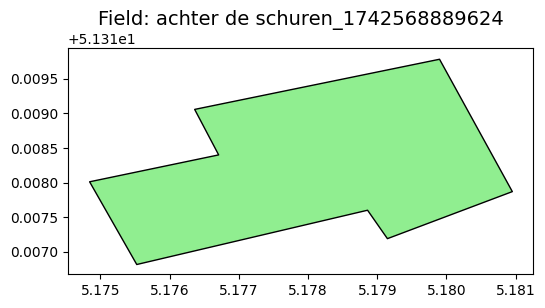

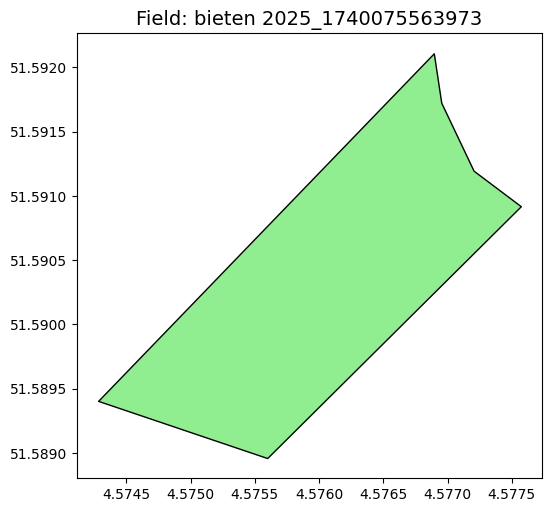

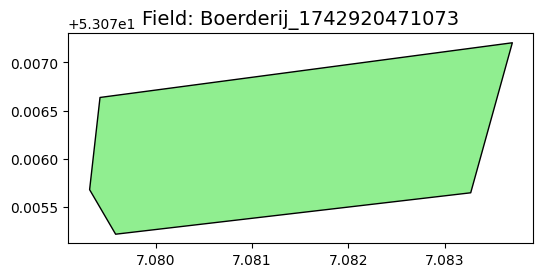

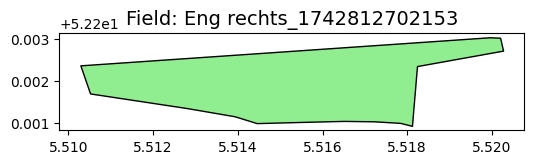

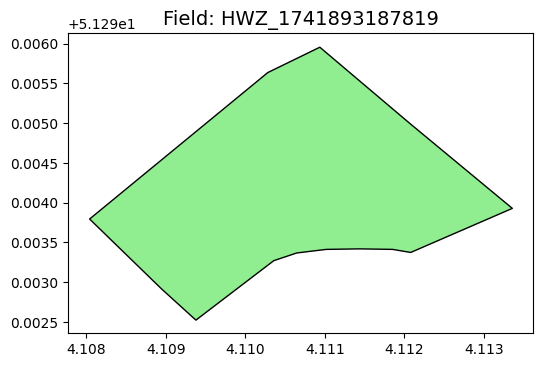

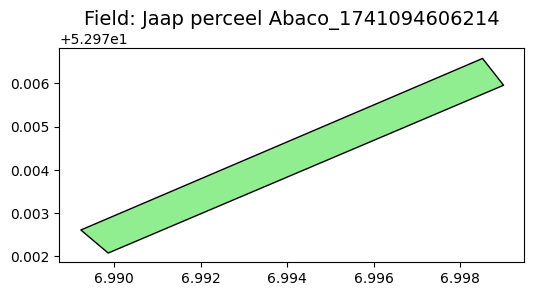

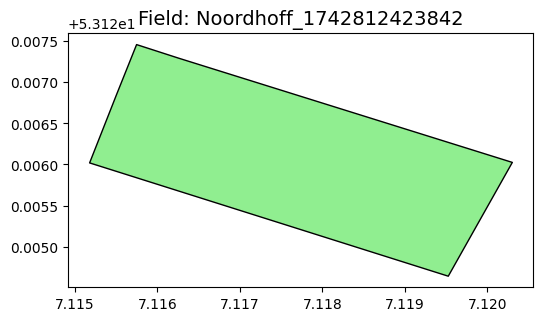

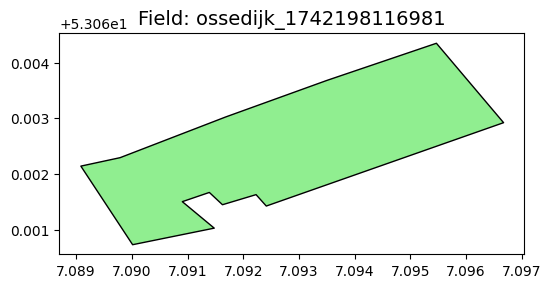

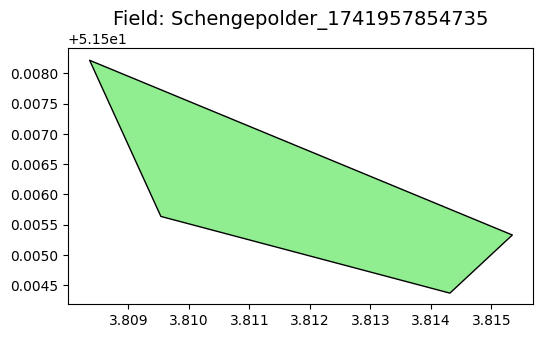

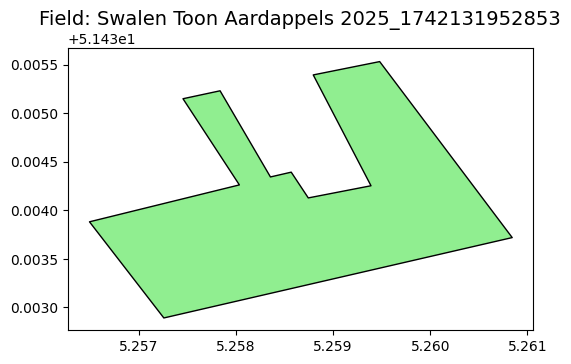

In [7]:
SM_API.output_format = 'gdf'
gdf_fields = SM_API.fields(project_id=project_id)
gdf_fields_subset = gdf_fields.iloc[0:10]
for index, row in gdf_fields_subset.iterrows():
    # Select single row as GeoDataFrame
    gdf_field = gdf_fields_subset.loc[[index]]  # double brackets to keep it as GeoDataFrame

    # Get field name from row (replace 'field_name' with the actual column name)
    field_name = row['name']  
    # Plot
    ax = gdf_field.plot(figsize=(6, 6), edgecolor='black', facecolor='lightgreen')
    ax.set_title(f"Field: {field_name}", fontsize=14)
    plt.show()

In [8]:
gdf_fields["created_at"]

0     2025-03-21T14:54:49.887748+00:00
1     2025-02-20T18:19:24.275647+00:00
2     2025-03-25T16:34:31.305824+00:00
3     2025-03-24T10:38:22.361128+00:00
4     2025-03-13T19:13:08.031066+00:00
5      2025-03-04T13:23:26.47965+00:00
6     2025-03-24T10:33:54.595981+00:00
7     2025-03-17T07:55:17.187158+00:00
8     2025-03-14T13:10:54.970642+00:00
9     2025-03-16T13:32:33.053162+00:00
10    2025-03-16T12:34:46.370893+00:00
Name: created_at, dtype: object

In [9]:
# Select fields for visualization
import pandas as pd

# Convert 'created_at' to datetime (timezone-aware), no format needed
gdf_fields = gdf_fields.copy()
gdf_fields["created_at"] = pd.to_datetime(gdf_fields["created_at"], format="ISO8601", utc=True)

# Calculate centroid for map center (mean of selected fields' centroids)
centroid = gdf_fields.geometry.centroid.union_all().centroid

# Calculate bounds to fit all selected fields
total_bounds = gdf_fields.total_bounds  # [minx, miny, maxx, maxy]
sw = [total_bounds[1], total_bounds[0]]  # (miny, minx)
ne = [total_bounds[3], total_bounds[2]]  # (maxy, maxx)

m = folium.Map(location=[centroid.y, centroid.x], tiles="OpenStreetMap")
m.fit_bounds([sw, ne])

# Add all selected polygons to the map with popups
for idx, row in gdf_fields.iterrows():
    popup_text = "<b>Field Details</b><br>"
    for col in gdf_fields.columns:
        if col == "geometry":
            continue
        popup_text += f"<b>{col}:</b> {row[col]}<br>"
        
    folium.GeoJson(
        row.geometry,
        name=row.name,
        popup=folium.Popup(popup_text, max_width=400)
    ).add_to(m)
m